In [1]:
import pandas as pd
pd.options.display.max_columns = None
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder, PolynomialFeatures
from sklearn.linear_model import LogisticRegression, PassiveAggressiveClassifier, Perceptron, SGDClassifier, RidgeClassifier
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold, cross_val_score, train_test_split, HalvingGridSearchCV
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier, BaggingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import f1_score
from datetime import datetime

### Preprocessing

In [3]:
df = pd.read_csv('fraudTrain.csv', index_col=0, parse_dates=['trans_date_trans_time'])

Based on discoveries of EDA, I delete some featurs and transform others.

In [5]:
df.rename(columns={'trans_date_trans_time':'time', 'amt':'amount'}, inplace=True)
#df['day'] = df['time'].dt.day
#df['weekday'] = df['time'].dt.weekday
#df['hour'] = df['time'].dt.hour
df['industry_code'] = df['cc_num'].astype(str).apply(lambda x: x[0:1]).astype(int)
df['age'] = (pd.to_datetime('today') - pd.to_datetime(df['dob'])).dt.days/365.25 
df.drop(columns=['time', 'first', 'last', 'street', 'trans_num', 'unix_time', 'cc_num', 'dob', 'lat', 'long', 'merch_lat', 'merch_long', 'zip', 'city', 'job', 'merchant'], inplace=True)

### Feature generation

In [7]:
y = df['is_fraud']
df.drop(columns='is_fraud', inplace=True)

str_cols = df.select_dtypes(include='object').columns
num_cols = df.select_dtypes(include='number').columns

In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        ('encoder', OneHotEncoder(drop='first', sparse_output=False, dtype=bool), str_cols),
        ('transformer', PolynomialFeatures(degree=3, include_bias=False), num_cols),
    ],
    remainder='passthrough', verbose_feature_names_out=False).set_output(transform='pandas')

df = preprocessor.fit_transform(df)
df.head()

,category_food_dining,category_gas_transport,category_grocery_net,category_grocery_pos,category_health_fitness,category_home,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel,gender_M,state_AL,state_AR,state_AZ,state_CA,state_CO,state_CT,state_DC,state_DE,state_FL,state_GA,state_HI,state_IA,state_ID,state_IL,state_IN,state_KS,state_KY,state_LA,state_MA,state_MD,state_ME,state_MI,state_MN,state_MO,state_MS,state_MT,state_NC,state_ND,state_NE,state_NH,state_NJ,state_NM,state_NV,state_NY,state_OH,state_OK,state_OR,state_PA,state_RI,state_SC,state_SD,state_TN,state_TX,state_UT,state_VA,state_VT,state_WA,state_WI,state_WV,state_WY,amount,city_pop,industry_code,age,amount^2,amount city_pop,amount industry_code,amount age,city_pop^2,city_pop industry_code,city_pop age,industry_code^2,industry_code age,age^2,amount^3,amount^2 city_pop,amount^2 industry_code,amount^2 age,amount city_pop^2,amount city_pop industry_code,amount city_pop age,amount industry_code^2,amount industry_code age,amount age^2,city_pop^3,city_pop^2 industry_code,city_pop^2 age,city_pop industry_code^2,city_pop industry_code age,city_pop age^2,industry_code^3,industry_code^2 age,industry_code age^2,age^3
0,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,4.97,3495.0,2.0,36.670773,24.7009,17370.15,9.94,182.253744,12215025.0,6990.0,128164.353183,4.0,73.341547,1344.745625,1.227635e+02,8.632965e+04,49.4018,9.058011e+02,6.070867e+07,34740.30,6.369768e+05,19.88,364.507488,6683.385756,4.269151e+10,24430050.0,4.479344e+08,13980.0,256328.706366,4.699886e+06,8.0,146.683094,2689.491250,49312.862149
1,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,107.23,149.0,6.0,46.387406,11498.2729,15977.27,643.38,4974.121533,22201.0,894.0,6911.723477,36.0,278.324435,2151.791425,1.232960e+06,1.713243e+06,68989.6374,5.333751e+05,2.380613e+06,95863.62,7.411441e+05,3860.28,29844.729199,230736.594489,3.307949e+06,133206.0,1.029847e+06,5364.0,41470.340862,3.206169e+05,216.0,1669.946612,12910.748549,99816.022208
2,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,220.11,4154.0,3.0,62.806297,48448.4121,914336.94,660.33,13824.294045,17255716.0,12462.0,260897.357974,9.0,188.418891,3944.630950,1.066398e+07,2.012547e+08,145345.2363,3.042865e+06,3.798156e+09,2743010.82,5.742612e+07,1980.99,41472.882136,868252.718402,7.168024e+10,51767148.0,1.083768e+09,37386.0,782692.073922,1.638600e+07,27.0,565.256674,11833.892850,247747.663224
3,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,45.00,1939.0,3.0,57.826146,2025.0000,87255.00,135.00,2602.176591,3759721.0,5817.0,112124.898015,9.0,173.478439,3343.863216,9.112500e+0

In [130]:
def evaluate():
    models = dict()
    
    models['Logistic Regression'] = LogisticRegression(random_state=1, max_iter=100000, class_weight='balanced')    
    #models['SVC'] = SVC(class_weight='balanced', random_state=1)
    models['SGD'] = SGDClassifier(random_state=1, class_weight='balanced')
    '''
    models['Nearest Neighbor'] = KNeighborsClassifier(3)
    models['Naive Bayes'] = GaussianNB()
    models['Decision Tree'] = DecisionTreeClassifier(random_state=1, class_weight='balanced')
    models['Random Forest'] = RandomForestClassifier(random_state=1, class_weight='balanced')
    models['MLPC'] = MLPClassifier(random_state=1)'''

    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=1, random_state=1)#(n_splits=5, n_repeats=10, random_state=1)
    
    res = pd.DataFrame()
    test_res = pd.DataFrame()

    for name, model in models.items():
        print(name, datetime.now())
        gs = GridSearchCV(model, cv=cv, n_jobs=3, param_grid={}, scoring='f1_weighted')
        gs.fit(X_train, y_train)
        test_res[name] = [f1_score(y_test, gs.predict(X_test), average='weighted')]

        scores = []
        for i in range(cv.get_n_splits()):
            scores.append(gs.cv_results_['split' + str(i) + '_test_score'][0])

        res[name] = scores

    plt.figure(figsize=(10, 8))
    sns.boxplot(data=res)

    for i in range(res.shape[1]):    
        plt.text(i - 0.4, res.iloc[:, i].max() + 0.0005, 'Test: ' + str(test_res.iloc[0, i])[:6], fontsize=8)

    plt.grid()

### Feature selection

In [10]:
scaler = ColumnTransformer(
    transformers=[('scaler', StandardScaler(), num_cols)],
                    remainder='passthrough', verbose_feature_names_out=False).set_output(transform='pandas')
        
df = scaler.fit_transform(df)
df.head()

,amount,city_pop,industry_code,age,category_food_dining,category_gas_transport,category_grocery_net,category_grocery_pos,category_health_fitness,category_home,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel,gender_M,state_AL,state_AR,state_AZ,state_CA,state_CO,state_CT,state_DC,state_DE,state_FL,state_GA,state_HI,state_IA,state_ID,state_IL,state_IN,state_KS,state_KY,state_LA,state_MA,state_MD,state_ME,state_MI,state_MN,state_MO,state_MS,state_MT,state_NC,state_ND,state_NE,state_NH,state_NJ,state_NM,state_NV,state_NY,state_OH,state_OK,state_OR,state_PA,state_RI,state_SC,state_SD,state_TN,state_TX,state_UT,state_VA,state_VT,state_WA,state_WI,state_WV,state_WY,amount^2,amount city_pop,amount industry_code,amount age,city_pop^2,city_pop industry_code,city_pop age,industry_code^2,industry_code age,age^2,amount^3,amount^2 city_pop,amount^2 industry_code,amount^2 age,amount city_pop^2,amount city_pop industry_code,amount city_pop age,amount industry_code^2,amount industry_code age,amount age^2,city_pop^3,city_pop^2 industry_code,city_pop^2 age,city_pop industry_code^2,city_pop industry_code age,city_pop age^2,industry_code^3,industry_code^2 age,industry_code age^2,age^3
0,-0.407826,-0.282589,-1.351318,-0.829704,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,24.7009,17370.15,9.94,182.253744,12215025.0,6990.0,128164.353183,4.0,73.341547,1344.745625,1.227635e+02,8.632965e+04,49.4018,9.058011e+02,6.070867e+07,34740.30,6.369768e+05,19.88,364.507488,6683.385756,4.269151e+10,24430050.0,4.479344e+08,13980.0,256328.706366,4.699886e+06,8.0,146.683094,2689.491250,49312.862149
1,0.230039,-0.293670,1.960079,-0.270974,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,11498.2729,15977.27,643.38,4974.121533,22201.0,894.0,6911.723477,36.0,278.324435,2151.791425,1.232960e+06,1.713243e+06,68989.6374,5.333751e+05,2.380613e+06,95863.62,7.411441e+05,3860.28,29844.729199,230736.594489,3.307949e+06,133206.0,1.029847e+06,5364.0,41470.340862,3.206169e+05,216.0,1669.946612,12910.748549,99816.022208
2,0.934149,-0.280406,-0.523469,0.673150,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,48448.4121,914336.94,660.33,13824.294045,17255716.0,12462.0,260897.357974,9.0,188.418891,3944.630950,1.066398e+07,2.012547e+08,145345.2363,3.042865e+06,3.798156e+09,2743010.82,5.742612e+07,1980.99,41472.882136,868252.718402,7.168024e+10,51767148.0,1.083768e+09,37386.0,782692.073922,1.638600e+07,27.0,565.256674,11833.892850,247747.663224
3,-0.158132,-0.287742,-0.523469,0.386780,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,2025.0000,87255.00,135.00,2602.176591,3759721.0,5817.0,11212

In [11]:
X_train, X_test, y_train, y_test = train_test_split(df, y, test_size=0.25, random_state=1)
del df

In [12]:
selector = ColumnTransformer(
    transformers=[('pca', PCA(n_components=0.99, copy=False), X_train.select_dtypes(include='number').columns)],
                    remainder='passthrough', verbose_feature_names_out=False).set_output(transform='pandas')
        
X_train = selector.fit_transform(X_train)
X_test = selector.fit_transform(X_test)

          Logistic Regression
Min: 0.9332083851112444 Max: 0.9380888672807804 Mean: 0.9352638463761453
          SGD
Min: 0.9315383211348768 Max: 0.9685843405417073 Mean: 0.9566142615053312


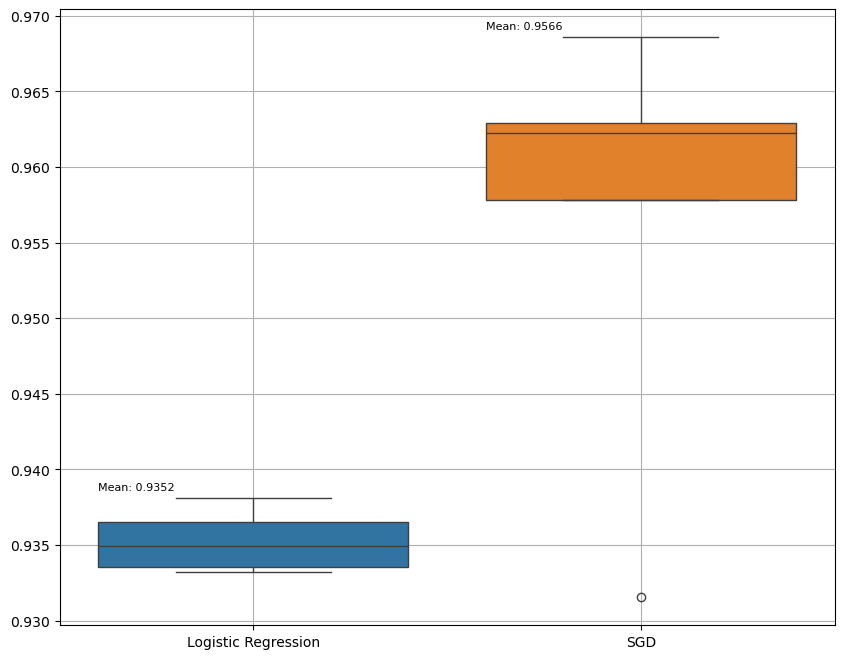

In [ ]:
evaluate(X_train, y_train)

### Handling imbalanced data

Logistic Regression 2024-11-09 15:32:00.217475
SGD 2024-11-09 15:32:04.376476


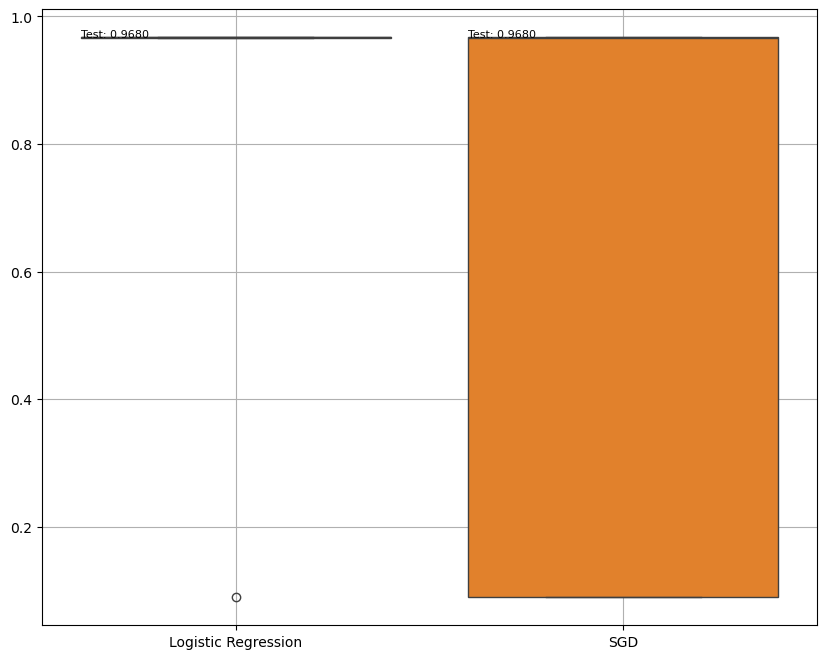

In [134]:
evaluate()

# OUTDATED

In [30]:
from imblearn.over_sampling import SMOTE
print(X_train.shape)
sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)
print(X_train.shape)

TypeError: validate_params() missing 1 required keyword-only argument: 'prefer_skip_nested_validation'

In [ ]:
from collections import Counter
from sklearn.datasets import make_classification
from imblearn.under_sampling import RandomUnderSampler

X, y = make_classification(n_classes=2, class_sep=2,
weights=[0.1, 0.9], n_informative=3, n_redundant=1, flip_y=0,
n_features=20, n_clusters_per_class=1, n_samples=1000, random_state=10)
print('Original dataset shape %s' % Counter(y))
rus = RandomUnderSampler(random_state=42)
X_res, y_res = rus.fit_resample(X, y)
print('Resampled dataset shape %s' % Counter(y_res))

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Apply LDA
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X, y)